<a href="https://colab.research.google.com/github/mjkloeckner/TB065/blob/main/tpe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico Especial

Señales y Sistemas (TB065) - Curso 2 - Grupo 11 - 1C2025 - FIUBA  
Martin Klöckner - mklockner@fi.uba.ar  
Pablo Martinez Madero -  
Ernesto Dei Castelli -    

## Análisis de la Señal de Habla

**Introduccion...**

Para la realización de los gráficos se utiliza el lenguaje de programación
[python](https://www.python.org) junto con las librerías
[scipy](https://docs.scipy.org/doc/scipy/index.html),
[matplotlib](https://matplotlib.org/) y
[numpy](https://numpy.org/doc/stable/index.html).

### Obtención y Muestra de Archivos

Se importan las librerías mencionadas previamente en un script
de python, incluyendo el método [urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) del módulo [urllib.request](https://docs.python.org/3/library/urllib.request.html#module-urllib.request) para obtener localmente los archivos a analizar.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.io import wavfile
from urllib.request import urlretrieve

Para obtener los archivos a analizar, se define una variable para almacenar el nombre de los archivos y se descargan utilizando el método [urlretrieve](https://docs.python.org/3/library/urllib.request.html#urllib.request.urlretrieve) proporcionando las respectivas urls y el nombre final que se desea que tengan los archivos una vez descargados.

In [2]:
short_sample_file_name = 'picasso_short.wav'
long_sample_file_name = 'picasso_long.wav'

urlretrieve('https://github.com/mjkloeckner/TB065/raw/main/data/picasso_short.wav', short_sample_file_name);
urlretrieve('https://github.com/mjkloeckner/TB065/raw/main/data/picasso_long.wav', long_sample_file_name);

Continuamos leyendo el contenido del primer archivo de nombre `picasso_short.wav`, para lo cual se utiliza el método [wavfile.read](https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.wavfile.read.html#read) de la librería [scipy](https://docs.scipy.org/doc/scipy/index.html). Esta función devuelve los datos y la tasa de muestreo leidos del archivo en formato WAV cuyo nombre recibe como argumento.

In [3]:
short_sample_rate, short_sample_data = wavfile.read(short_sample_file_name)

Para graficar los datos obtenidos resulta conveniente definir la función `graph_data`, la cual utiliza métodos del módulo [pyplot](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot) de la librería [matplotlib](https://matplotlib.org/) para generar los gráficos pedidos. Esto además permite evitar patrones repetitivos en el código,

In [16]:
def graph_data(x, y, title, figure_number=0, t=0, dt=0, a=0, da=0):
  figure, axis = plt.subplots(num=title, figsize=(12, 6))
  figure_caption = 'Figura ' + str(figure_number) + ': ' + title
  figure.text(.5, -0.02, figure_caption, ha='center', fontsize=12)

  plt.plot(x, y, label='Señal de Audio')
  axis.set(xlabel='Tiempo [s]', ylabel='Amplitud')
  plt.grid(True)
  plt.legend()
  plt.xlim([t, t+dt if t != 0 else x[-1]])

  if a != 0:
    axis.axvspan(a, a+da, color='skyblue', alpha=0.50)

  plt.ylim([-1, 1])
  plt.show()

Para poder graficar los datos se necesita saber a qué tiempo corresponde cada valor de la señal; para eso, se utiliza el método [arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html#numpy-arange) de la libreria [numpy](https://numpy.org/doc/stable/index.html). Este método devuelve un arreglo de números equidistantes del largo que recibe como parámetro, en este caso del largo de los datos leídos del archivo. Para convertirlo a segundos se divide por la tasa de muestreo, la cual también se obtiene cuando se lee el archivo.

In [5]:
short_sample_time = np.arange(len(short_sample_data)) / short_sample_rate

Para normalizar la amplitud de la señal entre -1 y 1 se divide por el valor máximo que toma el tipo de dato que almacena la señal. Para obtener este valor máximo se utiliza el método [iinfo](https://numpy.org/doc/stable/reference/generated/numpy.iinfo.html#numpy-iinfo) de la librería [numpy](https://numpy.org/doc/stable/index.html).

In [6]:
short_sample_data_normalized = short_sample_data / np.iinfo(short_sample_data.dtype).max

Se define una variable para almacenar el título de la figura, esto para posteriormente pasarlo como argumento a la función `graph_data`.

In [7]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'

Finalmente se grafica el pimer archivo utilizando la funcion `graph_data`

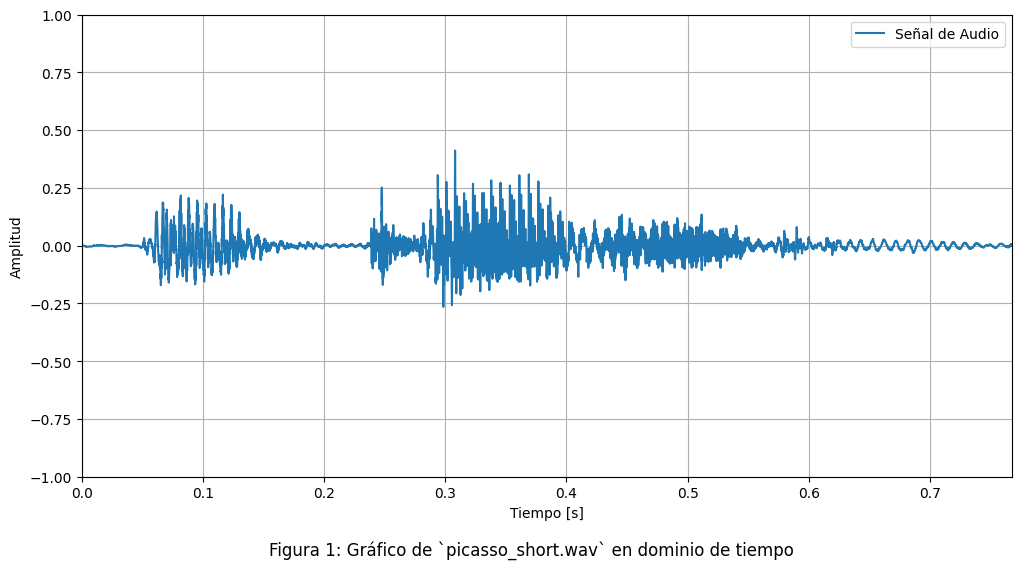

In [8]:
graph_data(short_sample_time, short_sample_data_normalized, title, 1);

Ahora realizamos exactamente el mismo procedimiento para el segundo archivo de aproximadamente el doble de duración.

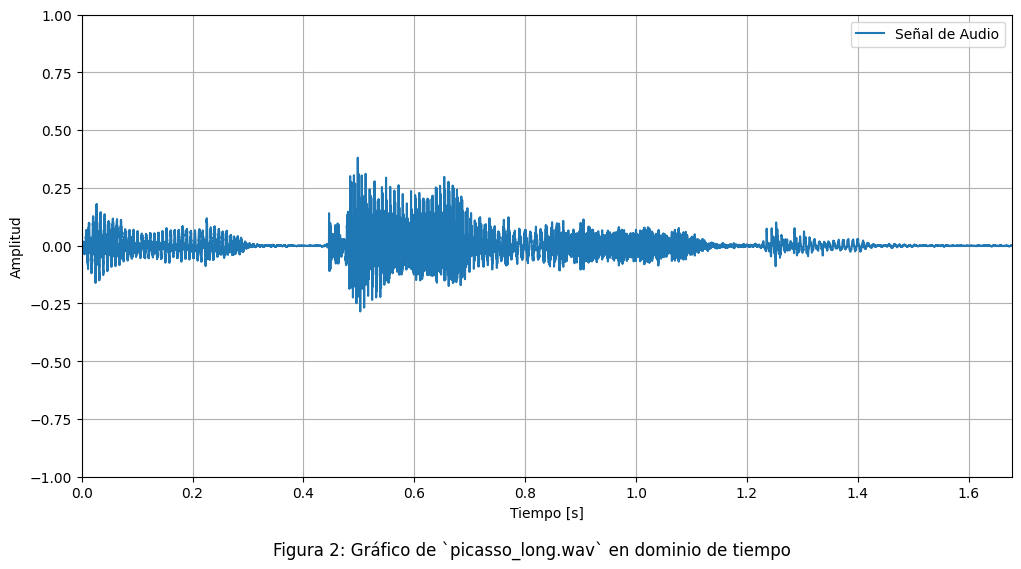

In [9]:
long_sample_rate, long_sample_data = wavfile.read(long_sample_file_name)
long_sample_time = np.arange(len(long_sample_data)) / long_sample_rate
long_sample_data_normalized = long_sample_data / np.iinfo(long_sample_data.dtype).max
title = 'Gráfico de `' + str(long_sample_file_name) + '` en dominio de tiempo'
graph_data(long_sample_time, long_sample_data_normalized, title, 2);

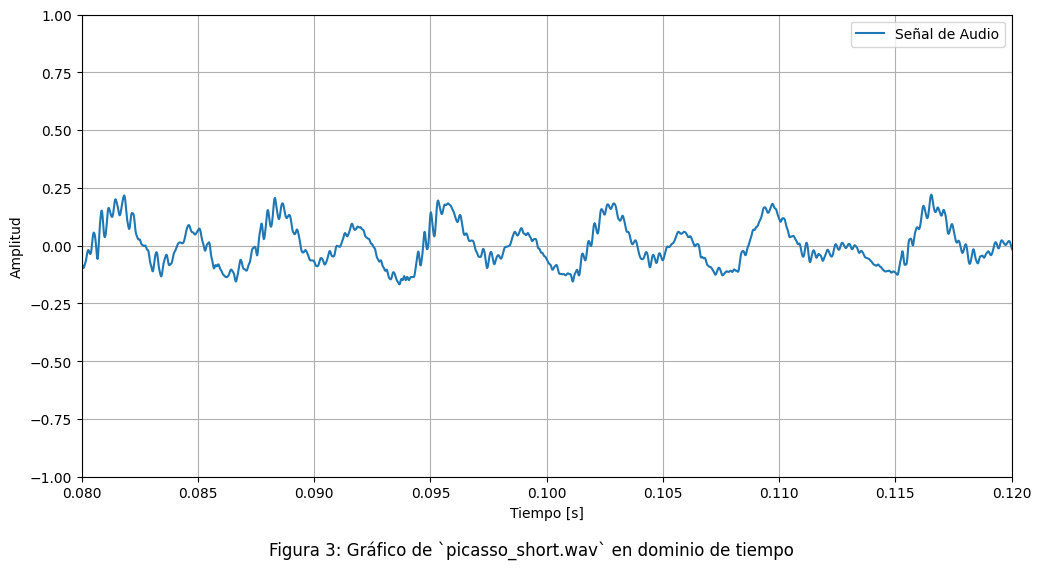

In [20]:
title = 'Gráfico de `' + str(short_sample_file_name) + '` en dominio de tiempo'
graph_data(short_sample_time, short_sample_data_normalized, title, 3, t=0.08, dt=0.04);